In [135]:
import numpy as np
from nibabel.loadsave import load
from nibabel.affines import apply_affine
from scipy.spatial import Delaunay
from lapy import TetMesh
from lapy.plot import plot_tet_mesh
from lapy.solver import Solver
from neuromodes import EigenSolver
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

In [145]:
nii = load('C:/Users/ipop0003/ModeDivergence/data/mesh/THA-lh_mask_scale=0_parcel=1.nii.gz')

In [17]:
# get voxel centers
voxel_coords = apply_affine(nii.affine, np.argwhere(nii.get_fdata() > 0))
voxel_coords

array([[  0., -20.,   6.],
       [  0., -20.,   8.],
       [  0., -18.,   8.],
       ...,
       [-24., -32.,   2.],
       [-24., -32.,   4.],
       [-24., -32.,   6.]], shape=(1288, 3))

In [52]:
# get voxel dimensions
print(nii.header.get_zooms())

(np.float32(2.0), np.float32(2.0), np.float32(2.0))


In [111]:
import numpy as np
from scipy.spatial import Delaunay

def voxel_alpha_shape(voxel_centers, max_edge_length):
    # 1. Compute the convex hull Delaunay triangulation
    delaunay = Delaunay(voxel_centers)
    
    # 2. Extract coordinates for the 4 vertices of every tetrahedron
    tets = delaunay.points[delaunay.simplices]
    
    # 3. Calculate the lengths of all 6 edges in each tetrahedron
    edge_lengths = np.array([
        np.linalg.norm(tets[:, 0, :] - tets[:, 1, :], axis=1),
        np.linalg.norm(tets[:, 0, :] - tets[:, 2, :], axis=1),
        np.linalg.norm(tets[:, 0, :] - tets[:, 3, :], axis=1),
        np.linalg.norm(tets[:, 1, :] - tets[:, 2, :], axis=1),
        np.linalg.norm(tets[:, 1, :] - tets[:, 3, :], axis=1),
        np.linalg.norm(tets[:, 2, :] - tets[:, 3, :], axis=1),
    ])
    
    # 4. Filter by maximum edge length
    max_edges = np.max(edge_lengths, axis=0)
    valid_mask = max_edges <= max_edge_length
    
    valid_tets = delaunay.simplices[valid_mask]
    valid_points = tets[valid_mask]
    
    # 5. Filter out zero-volume (degenerate) tetrahedra
    # Compute volume using the scalar triple product
    vec1 = valid_points[:, 0, :] - valid_points[:, 3, :]
    vec2 = valid_points[:, 1, :] - valid_points[:, 3, :]
    vec3 = valid_points[:, 2, :] - valid_points[:, 3, :]
    
    cross_prod = np.cross(vec2, vec3)
    vols = np.abs(np.sum(vec1 * cross_prod, axis=1)) / 6.0
    
    # Keep only tetrahedra with a volume significantly greater than 0
    final_valid_tets = valid_tets[vols > 1e-10]

    # Relabel the vertices to ensure they are contiguous and start from 0
    unique_vertices, new_indices = np.unique(final_valid_tets.flatten(), return_inverse=True)
    final_valid_tets = new_indices.reshape(final_valid_tets.shape)

    return TetMesh(voxel_centers[unique_vertices], final_valid_tets)

In [112]:
mesh = voxel_alpha_shape(voxel_coords, max_edge_length=2*np.sqrt(2) + 1e-5)

In [117]:
mesh.v

array([[  0., -20.,   6.],
       [  0., -20.,   8.],
       [  0., -18.,   8.],
       ...,
       [-24., -32.,   2.],
       [-24., -32.,   4.],
       [-24., -32.,   6.]], shape=(1221, 3))

In [101]:
plot_tet_mesh(mesh, plot_edges=True)

ValueError: Without boundary edges, all should have two triangles!

In [114]:
mesh.has_free_vertices()

False

In [116]:
EigenSolver(mesh)

ValueError: Without boundary edges, all should have two triangles!

In [118]:
def voxel_alpha_shape_jittered(voxel_centers, max_edge_length):
    # 1. Add microscopic noise to break the grid degeneracy
    jitter = np.random.normal(scale=1e-6, size=voxel_centers.shape)
    jittered_centers = voxel_centers + jitter
    
    # 2. Run Delaunay on the jittered points
    delaunay = Delaunay(jittered_centers)
    
    # 3. Extract the 4 vertices for every tetrahedron 
    # (Use the ORIGINAL un-jittered coordinates for distance checking)
    tets = voxel_centers[delaunay.simplices]
    
    # 4. Calculate lengths of all 6 edges
    edge_lengths = np.array([
        np.linalg.norm(tets[:, 0, :] - tets[:, 1, :], axis=1),
        np.linalg.norm(tets[:, 0, :] - tets[:, 2, :], axis=1),
        np.linalg.norm(tets[:, 0, :] - tets[:, 3, :], axis=1),
        np.linalg.norm(tets[:, 1, :] - tets[:, 2, :], axis=1),
        np.linalg.norm(tets[:, 1, :] - tets[:, 3, :], axis=1),
        np.linalg.norm(tets[:, 2, :] - tets[:, 3, :], axis=1),
    ])
    
    # 5. Filter by max edge length
    max_edges = np.max(edge_lengths, axis=0)
    valid_tets = delaunay.simplices[max_edges <= max_edge_length]
    
    return valid_tets

# --- Running the pipeline ---
nii = load('C:/Users/ipop0003/ModeDivergence/data/mesh/THA-lh_mask_scale=0_parcel=1.nii.gz')
voxel_coords = apply_affine(nii.affine, np.argwhere(nii.get_fdata() > 0))

# For a spacing of 2, face diagonals are 2*sqrt(2). 
# We use a threshold just above that to ensure face-connected cubes form tets.
valid_tets = voxel_alpha_shape_jittered(voxel_coords, max_edge_length=2*np.sqrt(2) + 1e-4)

# Create the mesh using the ORIGINAL perfect grid coordinates
mesh = TetMesh(voxel_coords, valid_tets)

# Check for free vertices - should be False now!
print(f"Has free vertices: {mesh.has_free_vertices()}")

plot_tet_mesh(mesh, plot_edges=True)

Has free vertices: True


ValueError: Degenerate (zero-volume) tetrahedra detected

### Hexahedral FEM

In [ ]:
# try voxel FEM directly
class VoxelMesh:
    """A simple container class to hold v and t for LaPy."""
    def __init__(self, v, t):
        self.v = np.array(v, dtype=np.float64)
        self.t = np.array(t, dtype=np.int32)

def build_lapy_vox_from_centers(mask_data, affine):
    """
    Builds a LaPy-compatible VoxelMesh using voxel centers as nodes.
    Only creates hexahedral elements where a full 2x2x2 block of mask voxels exists.
    """
    # 1. Get coordinates of all 1-voxels and map them to a 1D ID (0 to N-1)
    # Using np.where to get 3D indices
    indices_3d = np.argwhere(mask_data > 0)
    
    # Create a mapping from 3D (x,y,z) coordinate to the 1D vertex ID
    coord_to_id = {tuple(coords): i for i, coords in enumerate(indices_3d)}
    
    # 2. Extract true spatial coordinates (voxel centers) for the 'v' array
    v = [apply_affine(affine, coords) for coords in indices_3d]
    
    # 3. Build the hexahedral elements 't'
    # LaPy Ordering: Base CCW (z=0), then Top CCW (z=1)
    # Looking from above (assuming standard XYZ), CCW in XY is:
    # (0,0), (1,0), (1,1), (0,1)
    offsets = [
        (0, 0, 0), # Base 1
        (1, 0, 0), # Base 2
        (1, 1, 0), # Base 3
        (0, 1, 0), # Base 4
        (0, 0, 1), # Top 1
        (1, 0, 1), # Top 2
        (1, 1, 1), # Top 3
        (0, 1, 1)  # Top 4
    ]
    
    t = []
    
    # Iterate over every voxel to see if it can act as the "base" (0,0,0) of a cube
    for x, y, z in indices_3d:
        # Get the 3D coordinates for the 8 neighbors
        neighbors = [(x + dx, y + dy, z + dz) for dx, dy, dz in offsets]
        
        # Check if ALL 8 neighbors are inside the mask
        if all(n in coord_to_id for n in neighbors):
            # If yes, extract their 1D IDs and add as a hexahedron
            hex_ids = [coord_to_id[n] for n in neighbors]
            t.append(hex_ids)
            
    # Check for isolated boundary vertices that didn't make it into any cube
    t_flat = set(np.array(t).flatten())
    isolated = len(v) - len(t_flat)
    if isolated > 0:
        print(f"Warning: {isolated} boundary voxel centers were not part of any 2x2x2 block and will have zero mass/stiffness.")
        
    return VoxelMesh(v, t)

In [123]:
# --- How to use it ---
mesh_vox = build_lapy_vox_from_centers(nii.get_fdata(), nii.affine)
stiffness, mass = Solver._fem_voxels(mesh_vox, lump=False)

In [137]:
# detect and remove all-zero rows and columns from stiffness and mass matrices
zero_rows = np.where(stiffness.getnnz(axis=1) == 0)[0]
stiffness = stiffness[~np.isin(np.arange(stiffness.shape[0]), zero_rows)][:, ~np.isin(np.arange(stiffness.shape[1]), zero_rows)]
mass = mass[~np.isin(np.arange(mass.shape[0]), zero_rows)][:, ~np.isin(np.arange(mass.shape[1]), zero_rows)]

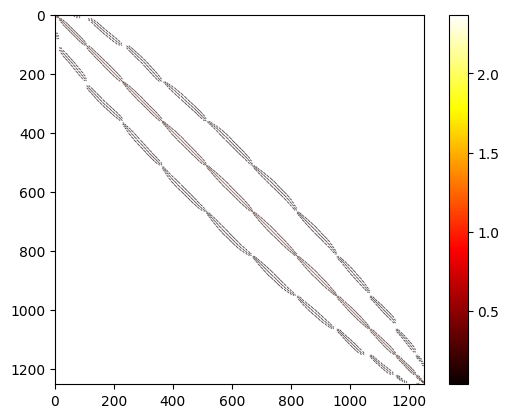

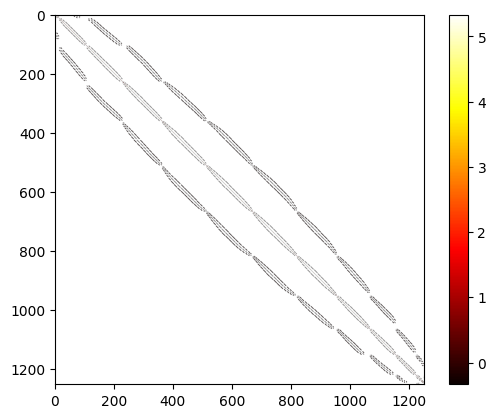

In [138]:
mass_vis = mass.toarray()
mass_vis[mass_vis == 0] = np.nan  # Set zero entries to NaN for better visualization

plt.imshow(mass_vis, cmap='hot')
plt.colorbar()
plt.show()

stiffness_vis = stiffness.toarray()
stiffness_vis[stiffness_vis == 0] = np.nan  # Set zero entries to NaN for better visualization

plt.imshow(stiffness_vis, cmap='hot')
plt.colorbar()
plt.show()

In [139]:
evals, emodes = eigsh(stiffness, k=6, M=mass, sigma=-0.01, which='LM')

In [140]:
evals, emodes

(array([-2.94902991e-17,  1.16292181e-02,  2.93829538e-02,  3.69073187e-02,
         5.13627515e-02,  5.90649080e-02]),
 array([[ 0.0122499 , -0.01708058, -0.0185855 , -0.00776548,  0.01421551,
         -0.01245231],
        [ 0.0122499 , -0.01696827, -0.01765994, -0.00666301,  0.01244528,
         -0.01177026],
        [ 0.0122499 , -0.01675886, -0.01523573, -0.00334793,  0.00800374,
         -0.01008554],
        ...,
        [ 0.0122499 ,  0.02612275, -0.03429495,  0.02712685, -0.02528909,
          0.00573949],
        [ 0.0122499 ,  0.02599453, -0.03382518,  0.02678168, -0.02453573,
          0.00561072],
        [ 0.0122499 ,  0.02622125, -0.0345886 ,  0.02735881, -0.02569182,
          0.00561967]], shape=(1254, 6)))

### MATLAB-like jittering

In [311]:
def robust_voxel_alpha_shape(voxel_centers, voxel_size):
    # 1. Jitter to break Qhull spherical degeneracy (MATLAB's secret)
    jitter = np.random.normal(scale=1e-9, size=voxel_centers.shape)
    pts_jittered = voxel_centers + jitter
    
    # 2. Delaunay on jittered points
    delau = Delaunay(pts_jittered)
    tets = delau.simplices
    
    # Use TRUE coordinates for distance math
    true_pts = voxel_centers[tets]
    
    # 3. Calculate max edge length per tetrahedron
    edges = [
        np.linalg.norm(true_pts[:, 0, :] - true_pts[:, 1, :], axis=1),
        np.linalg.norm(true_pts[:, 0, :] - true_pts[:, 2, :], axis=1),
        np.linalg.norm(true_pts[:, 0, :] - true_pts[:, 3, :], axis=1),
        np.linalg.norm(true_pts[:, 1, :] - true_pts[:, 2, :], axis=1),
        np.linalg.norm(true_pts[:, 1, :] - true_pts[:, 3, :], axis=1),
        np.linalg.norm(true_pts[:, 2, :] - true_pts[:, 3, :], axis=1),
    ]
    max_edges = np.max(edges, axis=0)
    
    # 4. Filter threshold: allow corner-connectivity to prevent orphaned vertices.
    # d * sqrt(3) is the max diagonal of a voxel cube.
    threshold = voxel_size * np.sqrt(3) + 1e-4
    valid_tets = tets[max_edges <= threshold]
    
    return valid_tets

# --- Execution ---
nii = load('C:/Users/ipop0003/ModeDivergence/data/mesh/THA-lh_mask_scale=0_parcel=1.nii.gz')
voxel_coords = apply_affine(nii.affine, np.argwhere(nii.get_fdata() > 0))

# Assuming a voxel size of 2mm based on your previous coordinate array
valid_tets = robust_voxel_alpha_shape(voxel_coords, voxel_size=2.0)

# Build the LaPy mesh
mesh = TetMesh(voxel_coords, valid_tets)

In [322]:
solver = EigenSolver(mesh).solve(500)

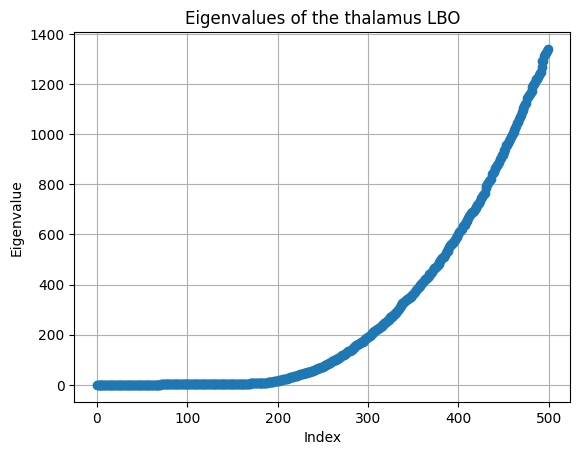

In [ ]:
# plot eigenvalues
plt.plot(solver.evals, 'o-', label='Eigenvalues')
plt.title('Eigenvalues of the thalamus LBO')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

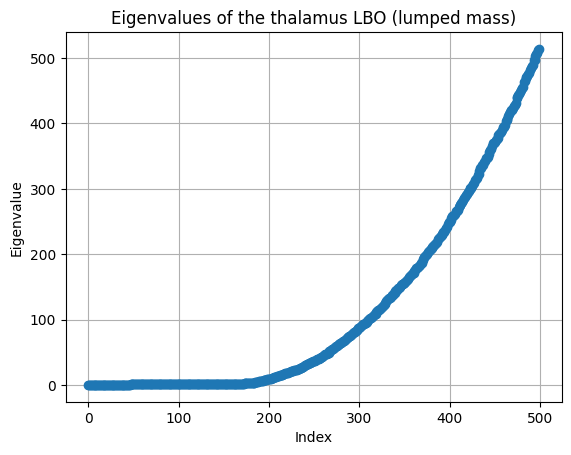

In [324]:
# plot eigenvalues with lumped mass matrix
solver = EigenSolver(mesh).solve(500, lump=True)
plt.plot(solver.evals, 'o-', label='Eigenvalues (lumped mass)')
plt.title('Eigenvalues of the thalamus LBO (lumped mass)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

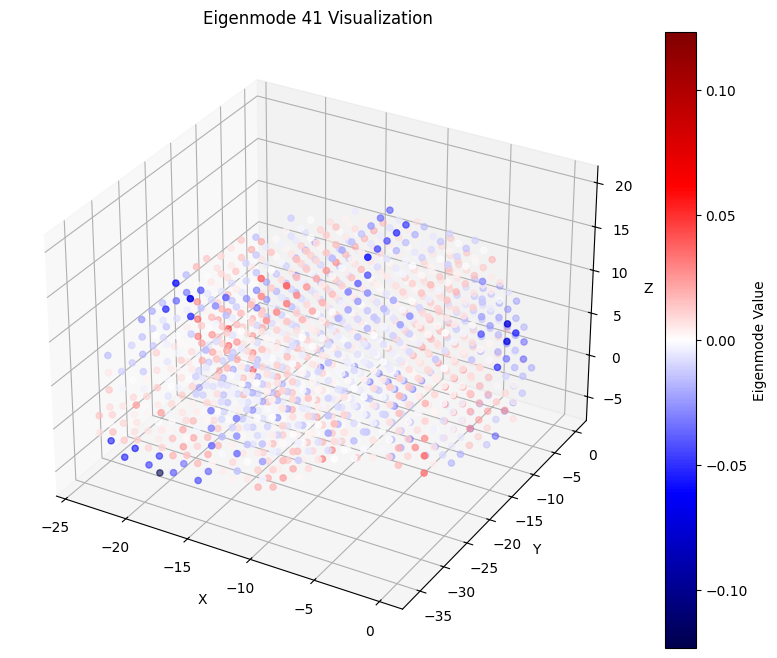

In [320]:
# visualise eigenmodes using matplotlib's 3D plotting capabilities
from mpl_toolkits.mplot3d import Axes3D

idx = 40
emode = solver.emodes[:, idx]
vmax = np.max(np.abs(emode))
vmin = -vmax

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.scatter(mesh.v[:, 0], mesh.v[:, 1], mesh.v[:, 2], c=emode, cmap='seismic', marker='o', vmin=vmin, vmax=vmax)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Eigenmode {idx+1} Visualization')
plt.colorbar(ax.collections[0], ax=ax, label='Eigenmode Value')
plt.show()

In [194]:
# remove zero-volume tetrahedra from the mesh

# compute tet vols via triple product
v1 = mesh.v[mesh.t[:, 0], :]
v2 = mesh.v[mesh.t[:, 1], :]
v3 = mesh.v[mesh.t[:, 2], :]
v4 = mesh.v[mesh.t[:, 3], :]

e1 = v2 - v1
e2 = v3 - v1
e3 = v4 - v1
cr = np.cross(e2, e3)
vols = np.abs(np.sum(e1 * cr, axis=1)) / 6

is_valid_tet = vols > 1e-10
print(f"Removed {np.sum(~is_valid_tet)}/{len(mesh.t)} zero-volume tetrahedra from the mesh.")

# remove zero-volume tets from the mesh and relabel vertices to ensure contiguous indexing
valid_tets = mesh.t[is_valid_tet]

valid_vertices, new_indices = np.unique(valid_tets.flatten(), return_inverse=True)
valid_tets = new_indices.reshape(valid_tets.shape)

mesh_cleaned = TetMesh(mesh.v[valid_vertices], valid_tets)
print(f"Mesh cleaned. Number of vertices: {len(mesh_cleaned.v)}, Number of tetrahedra: {len(mesh_cleaned.t)}")
mesh_cleaned.has_free_vertices()

Removed 1195/7207 zero-volume tetrahedra from the mesh.
Mesh cleaned. Number of vertices: 1288, Number of tetrahedra: 6012


False

In [195]:
solver = EigenSolver(mesh_cleaned)

ValueError: Without boundary edges, all should have two triangles!

### Graph Laplacian

In [255]:
from scipy.sparse import coo_matrix, diags, eye

def get_voxel_graph_laplacian(mask_data, voxel_spacing):
    """
    Computes the Graph Laplacian (Stiffness) and Mass matrices for a voxel mask.
    Assumes 6-connectivity (face-sharing) for a valid 3-manifold topology.
    """
    # 1. Get voxel indices and map them to a 1D ID
    indices = np.argwhere(mask_data > 0)
    num_voxels = len(indices)
    coord_to_id = {tuple(coords): i for i, coords in enumerate(indices)}
    
    # 2. Build Adjacency (A) and Degree (D) matrices
    # 6-connectivity offsets
    offsets = [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]
    
    rows = []
    cols = []
    data = []
    degrees = np.zeros(num_voxels)
    
    for i, (x, y, z) in enumerate(indices):
        neighbors = [(x+dx, y+dy, z+dz) for dx, dy, dz in offsets]
        
        valid_neighbors = 0
        for n in neighbors:
            if n in coord_to_id:
                j = coord_to_id[n]
                rows.append(i)
                cols.append(j)
                data.append(1.0)
                valid_neighbors += 1
                
        degrees[i] = valid_neighbors
        
    A = coo_matrix((data, (rows, cols)), shape=(num_voxels, num_voxels))
    D = diags(degrees)
    
    # 3. Compute L = D - A
    # The LBO is scaled by 1 / (spacing^2)
    L = (D - A) / (voxel_spacing**2)
    
    # 4. Mass Matrix
    # Every voxel has identical volume (spacing^3)
    M = eye(num_voxels) * (voxel_spacing**3)
    
    return L.tocsc(), M.tocsc()

# --- Execution ---
nii = load('C:/Users/ipop0003/ModeDivergence/data/mesh/THA-lh_mask_scale=0_parcel=1.nii.gz')
mask = nii.get_fdata()

# Assuming 2mm isotropic voxels
stiffness, mass = get_voxel_graph_laplacian(mask, voxel_spacing=2.0)

# Solve for eigenvalues: stiffness * x = lambda * mass * x
from scipy.sparse.linalg import eigsh
evals, emodes = eigsh(stiffness, M=mass, k=100, sigma=-1e-5, which='LM')

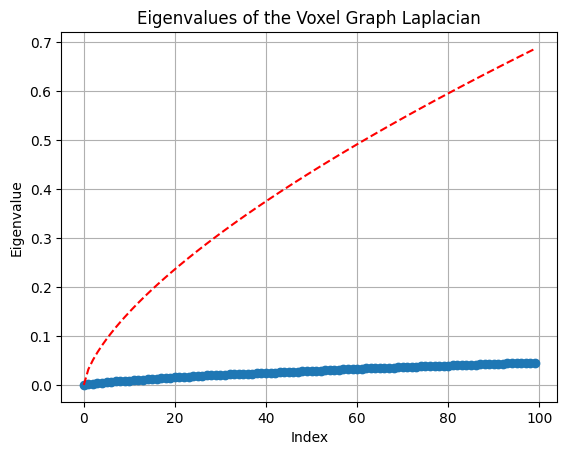

In [341]:
plt.plot(evals, 'o-')
# add a line at y=4x
plt.plot(np.arange(len(evals)), (6*np.pi**2/mass.sum())**(2/3)*np.arange(len(evals))**(2/3), 'r--', label="Weyl's Law")
plt.title('Eigenvalues of the Voxel Graph Laplacian')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

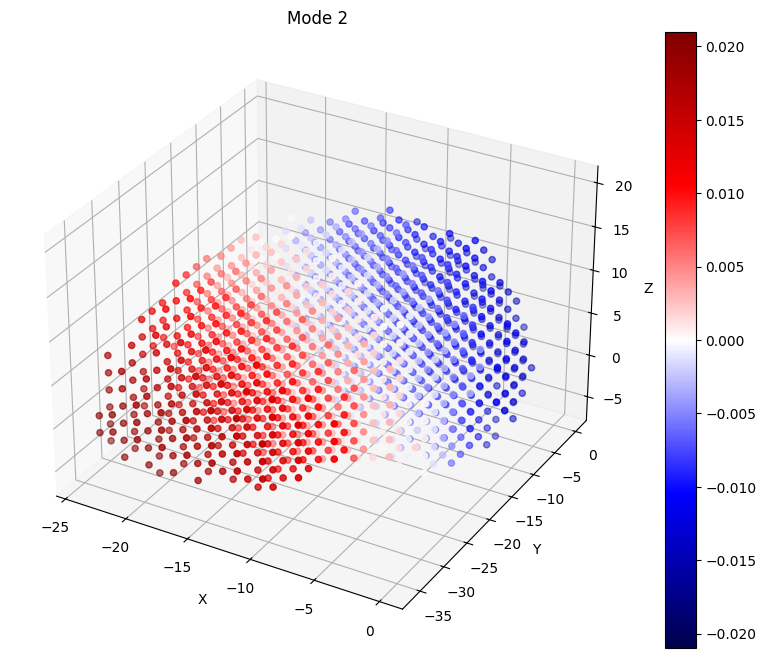

In [340]:
idx = 1
emode = emodes[:, idx]
vmax = np.max(np.abs(emode))
vmin = -vmax

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.scatter(mesh.v[:, 0], mesh.v[:, 1], mesh.v[:, 2], c=emode, cmap='seismic', marker='o', vmin=vmin, vmax=vmax)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Mode {idx+1}')
plt.colorbar(ax.collections[0], ax=ax)
plt.show()



IndexError: index 1287 is out of bounds for axis 1 with size 100

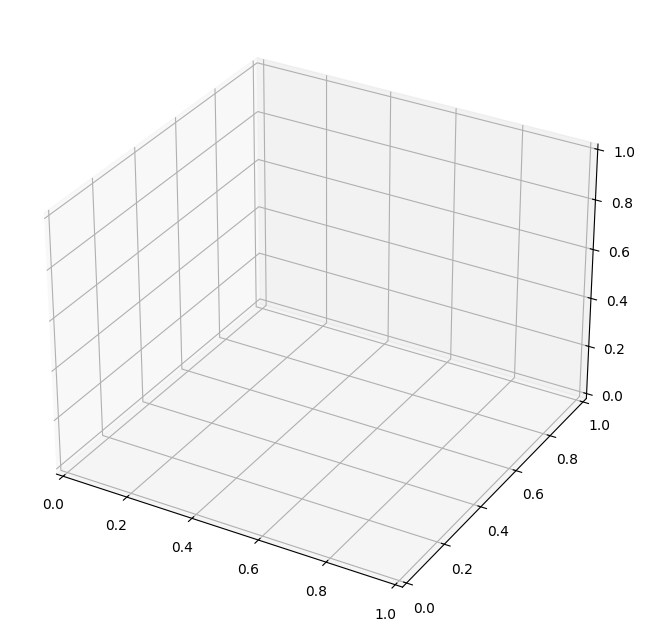

In [ ]:
ax = plt.figure(figsize=(10, 8)).add_subplot(111, projection='3d')

# reshape emode[:,idx] from (1288,) back to NIFTI's (91,109,91) shape for visualization
img = np.zeros_like(mask)
img[mask > 0] = emodes[:, idx]
print(img.shape)

# # Create a function that maps an array of values to a colormap (e.g., 'seismic') and returns facecolors for the voxels
# from matplotlib import cm
# def get_facecolors(data, cmap_name='seismic', vmin=None, vmax=None):
#     cmap = plt.get_cmap(cmap_name)
#     norm = plt.Normalize(vmin=vmin, vmax=vmax)
#     return cmap(norm(data))

# facecolors = get_facecolors(img[mask > 0], cmap_name='seismic', vmin=vmin, vmax=vmax)

facecolors = np.empty_like(img, dtype=object)
# Map the emode values to colors using a colormap
cmap = plt.get_cmap('seismic')

for idx, val in enumerate(img[mask > 0]):
    color = cmap((val - vmin) / (vmax - vmin))  # Normalize to [0,1] for colormap
    facecolors[mask > 0][idx] = color

print(facecolors.shape)
ax.voxels(mask > 0, facecolors=facecolors, edgecolor='k', alpha=1.0)
plt.show()

plt.figure().add_subplot(projection='3d').voxels()

### Weyl's Law

In [270]:
from neuromodes.io import fetch_example_vol

In [289]:
thal = fetch_example_vol('thalamus')
solver_thal = EigenSolver(thal).solve(1000)

In [290]:
solver_thal.geometry

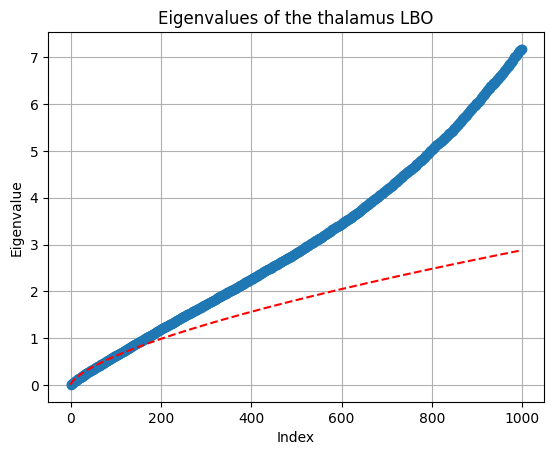

In [293]:
plt.plot(solver_thal.evals, 'o-', label='Thalamus Eigenvalues')
plt.plot(np.arange(len(solver_thal.evals)), (6*np.pi**2/solver_thal.mass.sum())**(2/3)*np.arange(len(solver_thal.evals))**(2/3), 'r--', label="Weyl's Law")
plt.title('Eigenvalues of the thalamus LBO')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

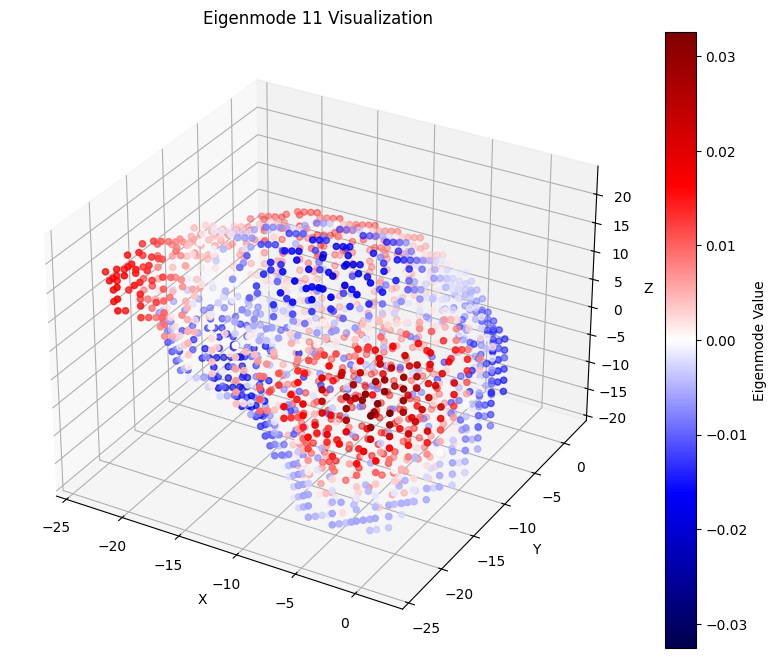

In [310]:
idx = 10
emode = solver_thal.emodes[:, idx]
vmax = np.max(np.abs(emode))
vmin = -vmax

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.scatter(solver_thal.geometry.v[:, 0], solver_thal.geometry.v[:, 1], solver_thal.geometry.v[:, 2], c=emode, cmap='seismic', marker='o', vmin=vmin, vmax=vmax)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Eigenmode {idx+1} Visualization')
plt.colorbar(ax.collections[0], ax=ax, label='Eigenmode Value')
plt.show()